In [ ]:
import os
import sys
import argparse

import seaborn as sns
import matplotlib.pyplot as plt

from data import *
from utils import *
from scipy import stats
from datetime import datetime
from matplotlib.patches import Rectangle

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from MIG import compute_mig

from BA import oh_binary_accuracy

In [3]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=10_000, help='Total # of samples')                     # Maybe 10_000
parser.add_argument('--mb_size', type=int, default=128, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=24, help='Dim of latent vector')                   # Maybe 16, 32
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')   # Maybe 16, 48 or 64 if too blurry
parser.add_argument('--x_fdim', type=int, default=48, help='Input x_fdim. See utils.py')            # Maybe 96 or 128
parser.add_argument('--y_fdim', type=int, default=16, help='Input y_fdim. See utils.py')            # Maybe 10, 16, 20, 32
parser.add_argument('--c_accu', type=float, default=25, help='Input weight on recons_error')        # Maybe 10, 25, 50, 100

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')     # Maybe 3e-4, 1e-4, 5e-5
parser.add_argument('--max_epochs', type=int, default=0, help='Input max_epoch for cut-off') # 500
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

In [4]:
_, xtest, ipVec_dim, nChannels = get_mnist_dataloader(args=opt)

In [5]:
def kPCA_1V(X, eps=1e-6):
    a = X @ X.T
    B = a.size(0)

    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    a = 0.5 * (a + a.T)  # numerical symmetry
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    return evecs[:, :opt.h_dim], evals

In [6]:
def kPCA(X, Y, eps=1e-6):
    a = X @ X.T + Y @ Y.T
    B = a.size(0)

    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    a = 0.5 * (a + a.T)  # numerical symmetry
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    return evecs[:, :opt.h_dim], evals

In [7]:
model = torch.load('out/Final.tar', weights_only=False)
model_sv = torch.load('out/Final-1V.tar', weights_only=False)

net1 = model['net1']
net2 = model['net2']
net3 = model['net3']
net4 = model['net4']

net1_sv = model_sv['net1']
net3_sv = model_sv['net3']

In [8]:
all_data_im = []
all_data_la = []

all_im_en_sv = []
all_im_en = []
all_la_en = []


with torch.no_grad():
    for datax, datay in xtest:
        datax = datax.to(opt.device)
        datay = datay.to(opt.device)

        all_data_im.append(datax)
        all_data_la.append(datay)

        x_en_sv = net1_sv(datax)
        x_en = net1(datax)
        y_en = net2(datay)

        all_im_en_sv.append(x_en_sv)
        all_im_en.append(x_en)
        all_la_en.append(y_en)

In [9]:
all_im_en_sv = torch.cat(all_im_en_sv, dim=0)[:1000]

all_la_en = torch.cat(all_la_en, dim=0)[:1000]
all_im_en = torch.cat(all_im_en, dim=0)[:1000]

all_data_im = torch.cat(all_data_im, dim=0)[:1000]
all_data_la = torch.cat(all_data_la, dim=0)[:1000]

# Only for plotting ---
all_im_de_sv = []
all_im_de = []
all_la_de = []
# ---

sv_losses = []
mv_im_losses = []
mv_la_losses = []
mv_total_losses = []

recon_loss1 = torch.nn.MSELoss()
recon_loss2 = torch.nn.CrossEntropyLoss()

In [10]:
with torch.no_grad():
    for i in range(10):
        start, stop = i*100, (i+1)*100
        h_test_sv, _ = kPCA_1V(all_im_en_sv[start:stop])
        h_test, _ = kPCA(all_im_en[start:stop], all_la_en[start:stop])

        U_test_sv = all_im_en_sv[start:stop].t() @ h_test_sv
        U_test = all_im_en[start:stop].t() @ h_test
        V_test = all_la_en[start:stop].t() @ h_test

        x_im_tilde_test_sv = net3_sv(h_test_sv @ U_test_sv.T)
        x_im_tilde_test = net3(h_test @ U_test.T)
        y_la_tilde_test = net4(h_test @ V_test.T)

        loss_im_sv = recon_loss1(x_im_tilde_test_sv.view(-1, ipVec_dim), all_data_im[start:stop].view(-1, ipVec_dim))
        loss_im_all = recon_loss1(x_im_tilde_test.view(-1, ipVec_dim), all_data_im[start:stop].view(-1, ipVec_dim))
        loss_la_all = recon_loss2(y_la_tilde_test.view(-1, 10), all_data_la[start:stop].argmax(dim=1).long())

        sv_losses.append(loss_im_sv.item())
        mv_im_losses.append(loss_im_all.item())
        mv_la_losses.append(loss_la_all.item())
        mv_total_losses.append((loss_im_all.item() + loss_la_all.item())/2)

        if i == 0:
            all_im_de_sv.append(x_im_tilde_test_sv.cpu()[:6])
            all_im_de.append(x_im_tilde_test.cpu()[:6])
            all_la_de.append(y_la_tilde_test.cpu()[:6])

        print(f'Batch {i+1}/10 - Reconstruction loss (images) 1V: {loss_im_sv.item():.4f}, All: {loss_im_all.item():.4f}, Labels: {loss_la_all.item():.4f}, Total: {(loss_im_all.item() + loss_la_all.item())/2:.4f}')

Batch 1/10 - Reconstruction loss (images) 1V: 0.0073, All: 0.0081, Labels: 0.0000, Total: 0.0041
Batch 2/10 - Reconstruction loss (images) 1V: 0.0073, All: 0.0080, Labels: 0.0000, Total: 0.0040
Batch 3/10 - Reconstruction loss (images) 1V: 0.0079, All: 0.0088, Labels: 0.0000, Total: 0.0044
Batch 4/10 - Reconstruction loss (images) 1V: 0.0083, All: 0.0095, Labels: 0.0000, Total: 0.0047
Batch 5/10 - Reconstruction loss (images) 1V: 0.0076, All: 0.0083, Labels: 0.0000, Total: 0.0042
Batch 6/10 - Reconstruction loss (images) 1V: 0.0078, All: 0.0091, Labels: 0.0000, Total: 0.0046
Batch 7/10 - Reconstruction loss (images) 1V: 0.0077, All: 0.0087, Labels: 0.0000, Total: 0.0043
Batch 8/10 - Reconstruction loss (images) 1V: 0.0082, All: 0.0099, Labels: 0.0000, Total: 0.0049
Batch 9/10 - Reconstruction loss (images) 1V: 0.0081, All: 0.0088, Labels: 0.0000, Total: 0.0044
Batch 10/10 - Reconstruction loss (images) 1V: 0.0079, All: 0.0089, Labels: 0.0000, Total: 0.0045


## Statistical Tests

In [11]:
t_stat, p_value = stats.ttest_rel(sv_losses, mv_im_losses)

print(f'T-statistic: {t_stat:.4f}, P-value: {p_value}')

T-statistic: -9.9942, P-value: 3.5954650034941958e-06


In [12]:
t_stat, p_value = stats.ttest_rel(sv_losses, mv_total_losses)

print(f'T-statistic: {t_stat:.4f}, P-value: {p_value}')

T-statistic: 65.8385, P-value: 2.172041437050674e-13


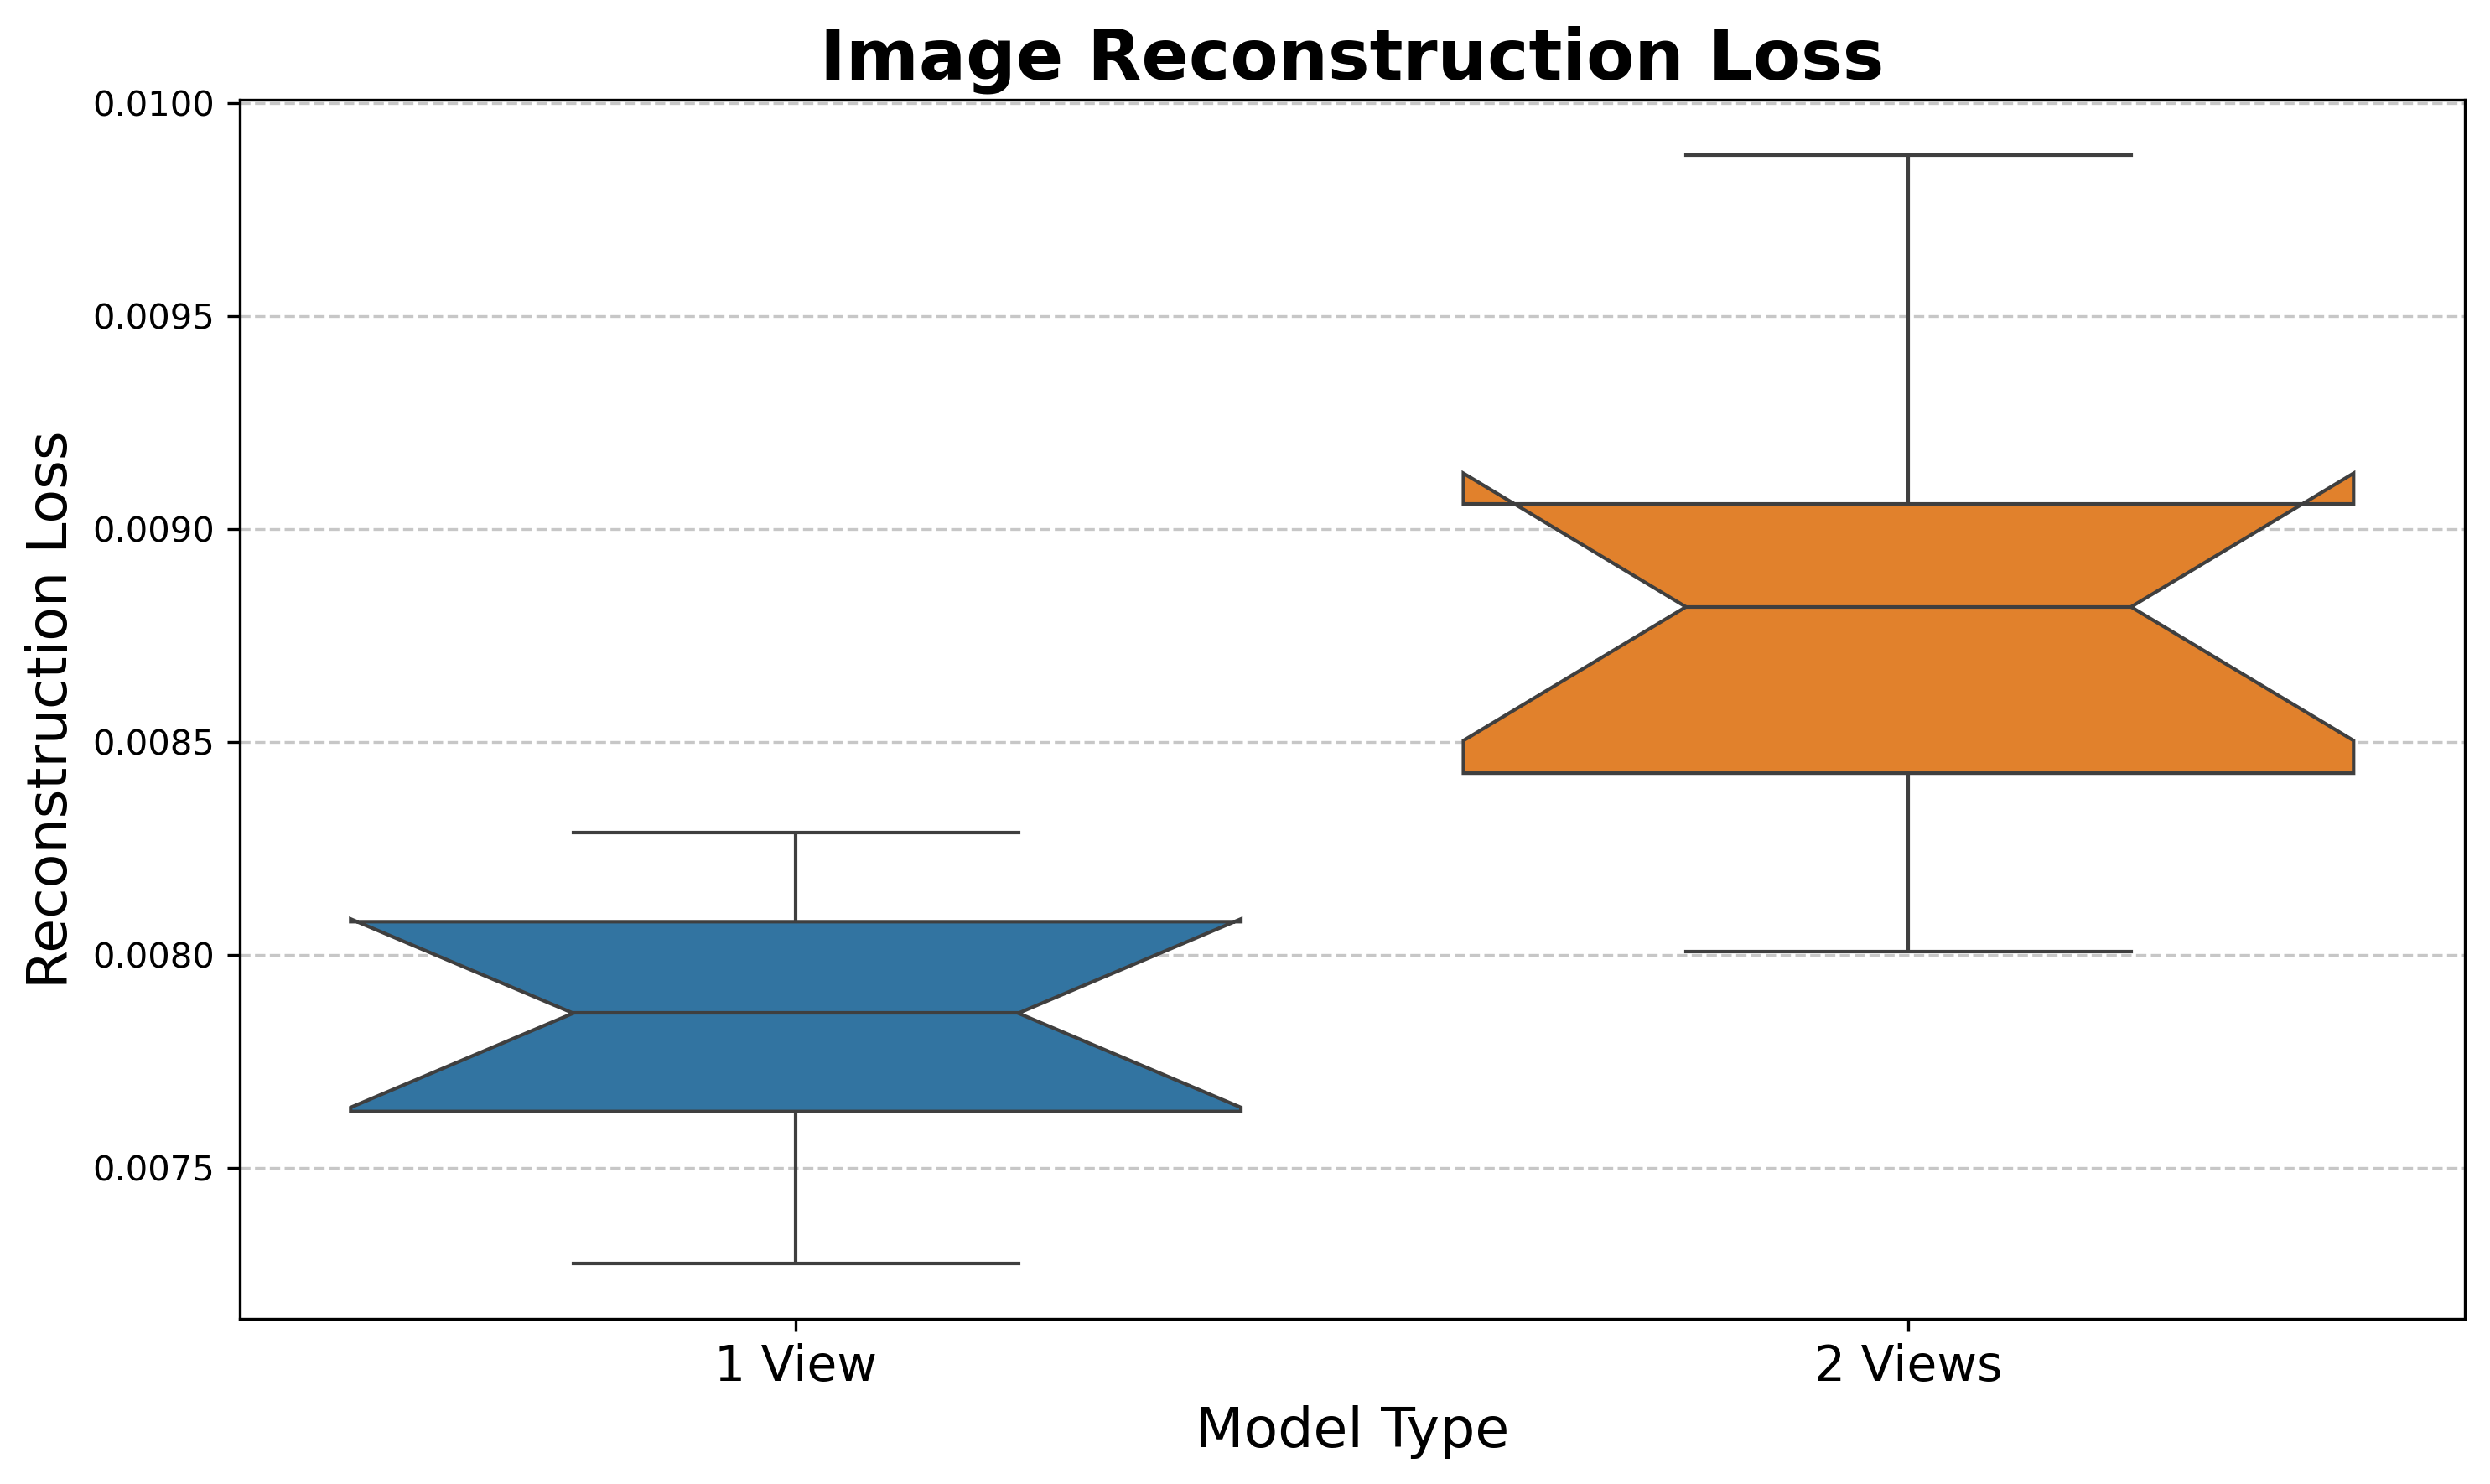

In [13]:
data = [sv_losses, mv_im_losses]
labels = ['1 View', '2 Views']

plt.figure(figsize=(10, 6), dpi=300)
plt.title('Image Reconstruction Loss', fontsize=20, fontweight='bold')
sns.boxplot(data=data, notch=True)

plt.xticks(ticks=range(len(labels)), labels=labels, fontsize=14)
plt.xlabel('Model Type', fontsize=16)
plt.ylabel('Reconstruction Loss', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('img/reconstruction_loss_comparison.png', dpi=300)

plt.show()

In [14]:
len(all_data_im)

1000

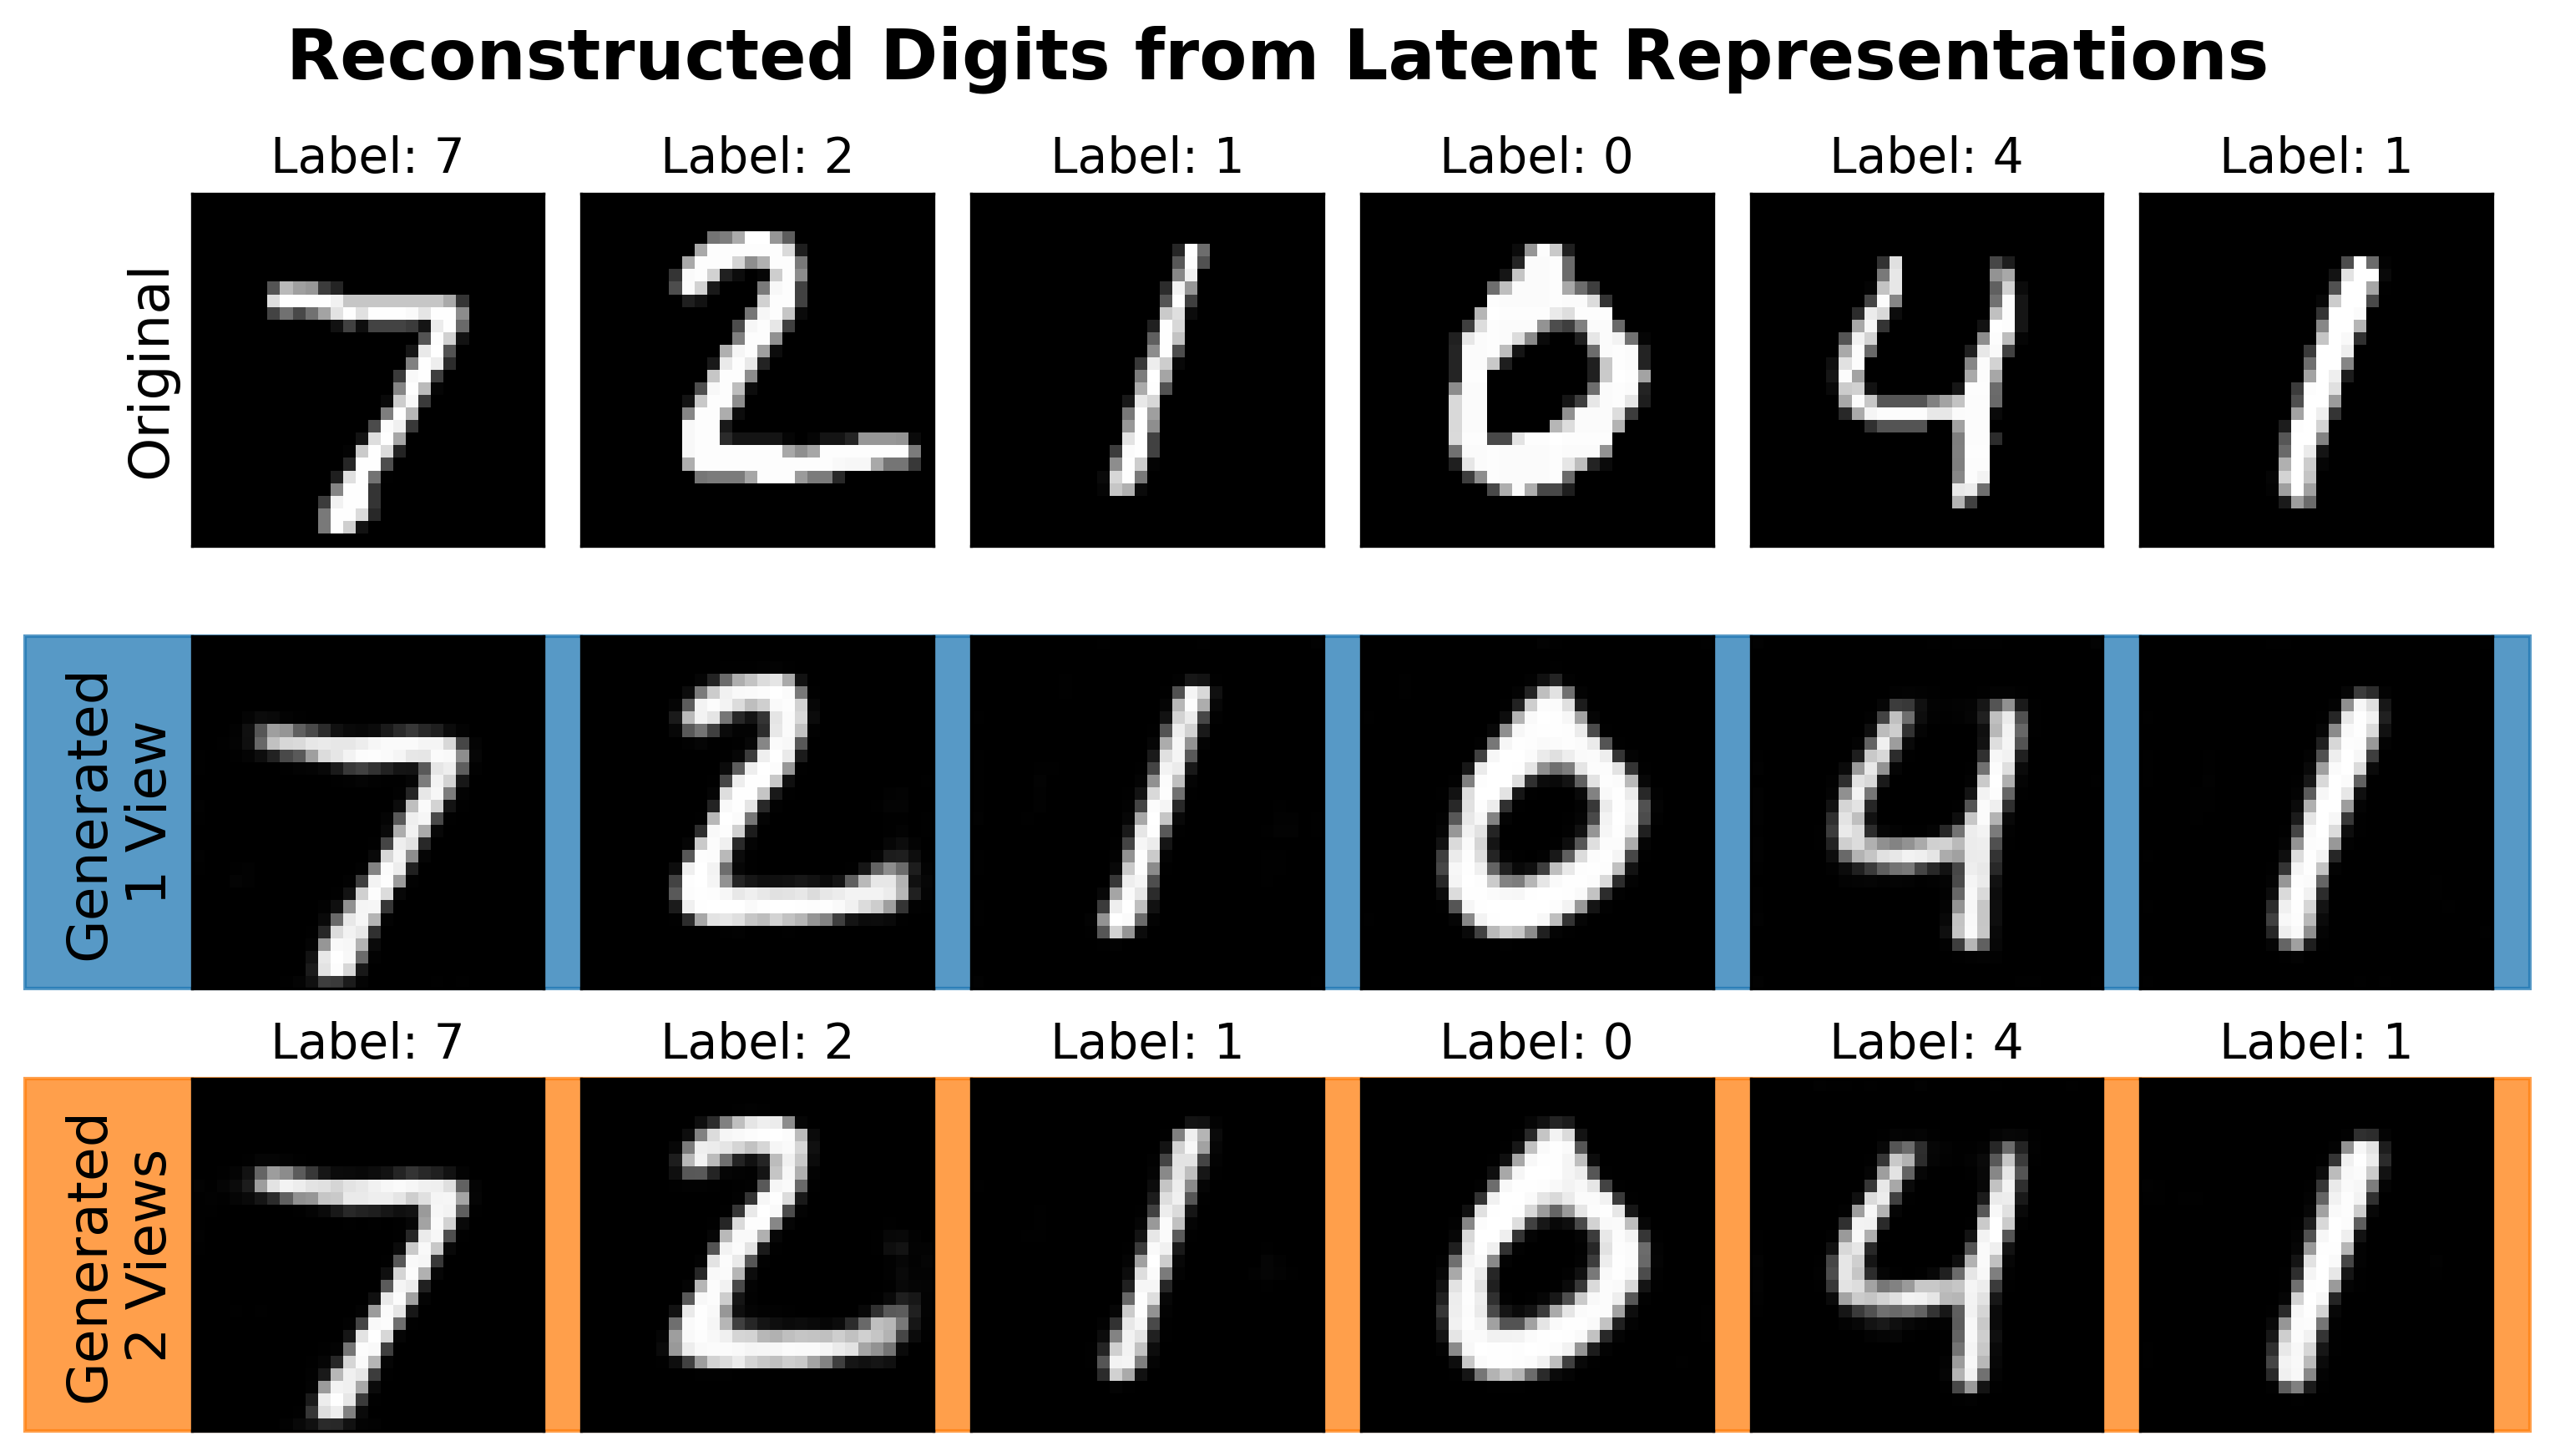

In [17]:
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(3, 6, figsize=(10, 6), dpi=300)

for idx in range(6):
    axes[0, 0].set_ylabel('\nOriginal', fontsize=16, rotation=90)
    axes[1, 0].set_ylabel('Generated\n1 View', fontsize=16, rotation=90)
    axes[2, 0].set_ylabel('Generated\n2 Views', fontsize=16, rotation=90)

    axes[0, idx].imshow(all_data_im[idx].reshape(28, 28), cmap='gray')
    axes[0, idx].set_title('Label: {}'.format(all_data_la[idx].argmax()), fontsize=14)

    axes[1, idx].imshow(all_im_de_sv[0][idx].reshape(28, 28), cmap='gray')

    axes[2, idx].imshow(all_im_de[0][idx].reshape(28, 28), cmap='gray')
    axes[2, idx].set_title('Label: {}'.format(all_la_de[0][idx].argmax()), fontsize=14)

    axes[0, idx].set_xticks([])
    axes[0, idx].set_yticks([])
    axes[1, idx].set_xticks([])
    axes[1, idx].set_yticks([])
    axes[2, idx].set_xticks([])
    axes[2, idx].set_yticks([])

plt.suptitle('Reconstructed Digits from Latent Representations', fontsize=20, fontweight='bold')
plt.tight_layout()

row_colors = [None, 'tab:blue', 'tab:orange']

for i, color in enumerate(row_colors):
    if color is not None:
        row_pos = axes[i, 0].get_position()
        y0 = row_pos.y0
        height = row_pos.height

        fig.patches.append(
            Rectangle(
                (0, y0),
                1,
                height,
                transform=fig.transFigure,
                color=color,
                alpha=0.75,
                zorder=-1
            )
        )

plt.savefig('img/reconstruction_loss_comparison.png', dpi=300)
plt.show()